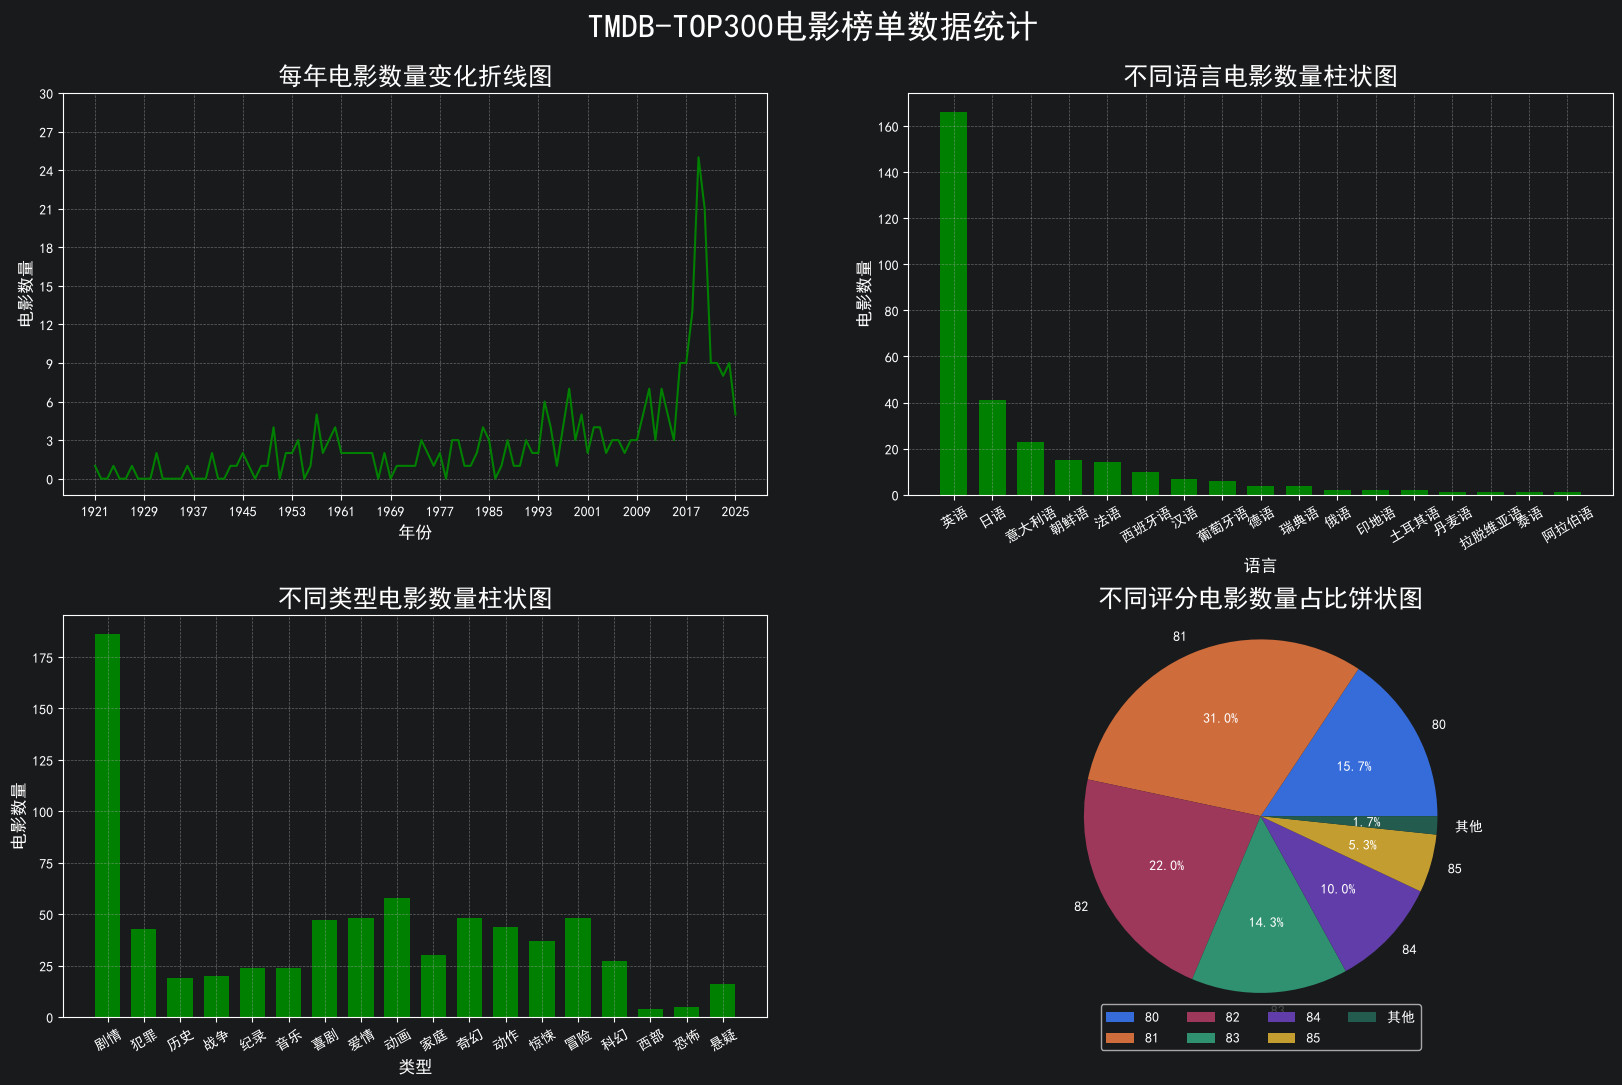

In [36]:
from pandas import Series
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

# 展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), dpi=100)
fig.suptitle('TMDB-TOP300电影榜单数据统计', fontsize=24, x=0.5, y=0.95)  # 添加画布标题 -> x,y 表示标题相对于画布的位置
fig.subplots_adjust(hspace=0.3, wspace=0.2)  # 调整子图间距 -> hspace: 垂直间距, wspace: 水平间距

# 获取子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
# int64: 整型数字(不支持空值)
# Int64:整型数字(支持空值)
# float64: 浮点型数字(支持空值)
data = pd.read_csv('./data/movies.csv', usecols=['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'],
                   dtype={'年份': 'Int64'})

# 1. 需求一: 统计TOP300的电影中, 每年的电影数量变化(折线图)
# 1.1 缺失值、异常值处理
# data.isnull().sum()
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 1.2 分组统计
year_count = data.groupby('年份')['电影名'].count()

# 1.3 组装数据
# x轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year + 1)]

# y轴数据
y = [int(year_count.get(i, 0)) for i in x]

# 1.4 绘制折线图
axes1.plot(x, y, color='green')  # 折线图
axes1.set_title('每年电影数量变化折线图', fontsize=18)  # 添加子图标题
axes1.set_xlabel('年份', fontsize=12)  # 添加X轴标签
axes1.set_ylabel('电影数量', fontsize=12)  # 添加Y轴标签

axes1.set_xticks(x[::8])  # 设置X轴刻度间隔
y_ticks = [i for i in range(0, 31, 3)]
axes1.set_yticks(y_ticks)  # 设置Y轴刻度间隔
axes1.grid(linestyle='--', alpha=0.5)  # 添加网格线

# 2. 需求二: 统计对比不同语言的电影数量(柱状图)
# 2.1 获取不同语言对应的电影数量
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()
y_language = language_count.values.tolist()

# 2.2 绘制柱状图
axes2.bar(x_language, y_language, color='green', width=0.7)  # 柱状图
axes2.set_title('不同语言电影数量柱状图', fontsize=18)  # 添加子图标题
axes2.set_xlabel('语言', fontsize=12)  # 添加X轴标签
axes2.set_ylabel('电影数量', fontsize=12)  # 添加Y轴标签
axes2.grid(linestyle='--', alpha=0.5)  # 添加网格线
axes2.tick_params(axis='x', rotation=30)  # 设置X轴刻度旋转30度

# 3. 需求三:统计对比不同类型电影数量(柱状图)
# 3.1 获取不同类型对应的电影数量
type_count = {}  # {类型: 数量}
for types in data['类型'].str.split(','):  # 类型是列表
    for type in types:  # 类型是字符串
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

x_types = list(type_count.keys())  # 类型列表
y_nums = list(type_count.values())  # 数量列表

# 3.2 绘制柱状图
axes3.bar(x_types, y_nums, color='green', width=0.7)  # 柱状图
axes3.set_title('不同类型电影数量柱状图', fontsize=18)  # 添加子图标题
axes3.set_xlabel('类型', fontsize=12)  # 添加X轴标签
axes3.set_ylabel('电影数量', fontsize=12)  # 添加Y轴标签
axes3.grid(linestyle='--', alpha=0.5)  # 添加网格线
axes3.tick_params(axis='x', rotation=30)  # 设置X轴刻度旋转30度

# 4. 需求四: 统计不同评分电影数量占比(饼状图)
# 4.1 获取不同评分对应的电影数量
scores_count = data.groupby('评分')['评分'].count()

# 合并小数据(比例 < 2%)为其他
total = scores_count.sum()
large_scores: Series = scores_count[scores_count >= total * 0.02]  # 大数据, 比例 >= 2%
small_scores: Series = scores_count[scores_count < total * 0.02]  # 小数据, 比例 < 2%

if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist()  # 评分列表
nums = large_scores.values.tolist()  # 数量列表

# 4.2 绘制饼状图
axes4.pie(nums, labels=scores, autopct='%1.1f%%', startangle=0, radius=1.1)  # 饼状图 -> startangle: 起始角度
axes4.set_title('不同评分电影数量占比饼状图', fontsize=18)  # 添加子图标题
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))  # 添加图例

# 5. 保存图片
plt.savefig('data/TMDB-TOP300电影榜单数据统计.png')

plt.show()  # 显示图片